In [22]:
import pandas as pd

In [23]:
df = pd.read_csv("./trump_posts_features_2017_2026.csv")

df.head()

,Timestamp,Content,Likes,Retweets,Platform,kw_china,kw_taiwan,kw_tariffs,kw_sanctions,kw_chips,kw_tech,kw_ai,kw_market,kw_supply_chain,kw_military,vader_compound,emotion_label,emotion_score,weighted_vader
0,2017-01-01 00:00:00+00:00,RT @IvankaTrump: 2016 has been one of the most...,0,11210,Twitter_Legacy,0,0,0,0,0,0,0,0,0,0,0.9765,joy,0.792413,0.0
1,2017-01-01 00:00:00+00:00,RT @DonaldJTrumpJr: Happy new year everyone. #...,0,5548,Twitter_Legacy,0,0,0,0,0,0,0,0,0,0,0.5719,fear,0.741192,0.0
2,2017-01-01 00:00:00+00:00,RT @EricTrump: 2016 was such an incredible yea...,0,5601,Twitter_Legacy,0,0,0,0,0,0,0,0,0,0,0.8118,fear,0.313381,0.0
3,2017-01-01 00:00:00+00:00,RT @Reince: Happy New Year + God's blessings t...,0,5811,Twitter_Legacy,0,0,0,0,0,0,0,0,0,0,0.8172,joy,0.786424,0.0
4,2017-01-01 00:00:00+00:00,RT @DanScavino: On behalf of our next #POTUS &...,0,4562,Twitter_Legacy,0,0,0,0,0,0,0,0,0,0,0.0000,joy,0.873758,0.0


總貼文數: 26380
------------------------------
【各關鍵字出現次數】
kw_china        2228
kw_tariffs       515
kw_tech          438
kw_sanctions     204
kw_chips          53
kw_taiwan         12
kw_ai              8
dtype: int64
------------------------------
【各關鍵字佔總貼文的比例 (%)】
kw_china        8.445792
kw_tariffs      1.952237
kw_tech         1.660349
kw_sanctions    0.773313
kw_chips        0.200910
kw_taiwan       0.045489
kw_ai           0.030326
dtype: float64


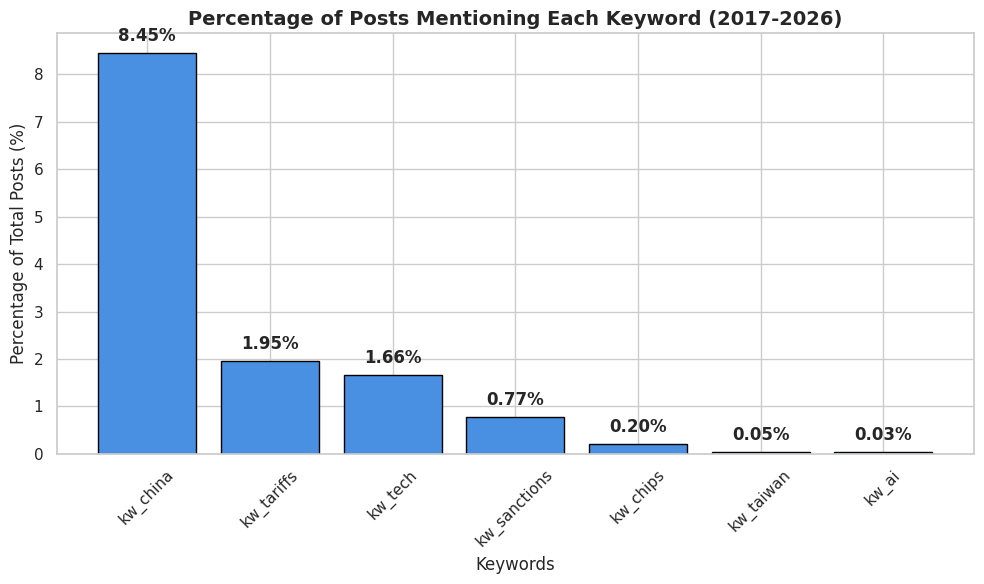

In [24]:
import matplotlib.pyplot as plt

# 1. 整理所有 kw_ 開頭的欄位名稱
kw_columns = ['kw_china', 'kw_taiwan', 'kw_tariffs', 'kw_sanctions', 'kw_chips', 'kw_tech', 'kw_ai']

# 2. 計算每個關鍵字出現的次數 (因為標籤是 0 或 1，直接加總就是次數)
kw_counts = df[kw_columns].sum()

# 3. 計算比例：次數 / 總貼文數 * 100 (轉換為百分比)
total_posts = len(df)
kw_proportions = (kw_counts / total_posts) * 100

# 4. 將比例由高到低排序，讓圖表與數據閱讀起來更直覺
kw_proportions = kw_proportions.sort_values(ascending=False)

# --- 輸出文字結果 ---
print(f"總貼文數: {total_posts}")
print("-" * 30)
print("【各關鍵字出現次數】")
print(kw_counts.sort_values(ascending=False))
print("-" * 30)
print("【各關鍵字佔總貼文的比例 (%)】")
print(kw_proportions)

# --- 繪製資料視覺化圖表 ---
plt.figure(figsize=(10, 6))
bars = plt.bar(kw_proportions.index, kw_proportions.values, color='#4A90E2', edgecolor='black')

# 在每個柱子上方加上百分比數字
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (kw_proportions.max() * 0.02), 
             f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

# 設定圖表標題與軸標籤
plt.title('Percentage of Posts Mentioning Each Keyword (2017-2026)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Posts (%)', fontsize=12)
plt.xlabel('Keywords', fontsize=12)
plt.xticks(rotation=45, fontsize=11) # 將X軸標籤旋轉45度避免文字重疊

plt.tight_layout()
plt.show()